# Olist E-Commerce — Data Cleaning & Exploratory Data Analysis

**Tools:** Python · Pandas · Matplotlib · Jupyter Notebook

**Dataset:** [Brazilian E-Commerce Public Dataset by Olist](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce) (Kaggle) — real, anonymised data of about 100k orders placed on Brazilian marketplaces between 2016 and 2018.

## Project goal
Understand how the marketplace performs and what drives customer satisfaction, starting from raw relational data (8 CSV tables) that first has to be inspected, cleaned and joined.

## Business questions
1. How did orders and revenue evolve over time, and when are the peaks?
2. Which product categories and customer states generate most of the revenue?
3. How do customers pay (payment type, instalments)?
4. How good is delivery performance — actual vs. promised delivery date?
5. Does late delivery hurt customer reviews?
6. How loyal are customers (repeat purchases)?

## Workflow
Inspect → Clean → Join → Explore & visualise → Findings & recommendations

> **How to run:** download the dataset from Kaggle, unzip it, put the CSV files in a folder called `data/` next to this notebook, then *Kernel → Restart & Run All*. Every chart is also saved automatically in `images/`.

## 0. Setup

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from IPython.display import display

# ------------------------------------------------------------------ settings
DATA_DIR = Path("data")      # folder with the CSV files downloaded from Kaggle
IMG_DIR = Path("images")     # every chart is saved here (handy for the README)
IMG_DIR.mkdir(exist_ok=True)

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

plt.rcParams.update({
    "figure.figsize": (10, 5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.alpha": 0.25,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
})
BLUE, ORANGE, GREY = "#2E6F95", "#E4572E", "#BFC5CC"


def save_fig(name):
    """Tidy the layout, save the figure to ./images and display it."""
    plt.tight_layout()
    plt.savefig(IMG_DIR / f"{name}.png", dpi=150, bbox_inches="tight")
    plt.show()

## 1. Load the data

In [2]:
files = {
    "orders":      "olist_orders_dataset.csv",
    "items":       "olist_order_items_dataset.csv",
    "payments":    "olist_order_payments_dataset.csv",
    "reviews":     "olist_order_reviews_dataset.csv",
    "customers":   "olist_customers_dataset.csv",
    "products":    "olist_products_dataset.csv",
    "sellers":     "olist_sellers_dataset.csv",
    "translation": "product_category_name_translation.csv",
}

orders, items, payments, reviews, customers, products, sellers, translation = (
    pd.read_csv(DATA_DIR / f) for f in files.values()
)

tables = {
    "orders": orders, "items": items, "payments": payments, "reviews": reviews,
    "customers": customers, "products": products, "sellers": sellers, "translation": translation,
}
print({name: df.shape for name, df in tables.items()})

{'orders': (99441, 8), 'items': (112650, 7), 'payments': (103886, 5), 'reviews': (99224, 7), 'customers': (99441, 5), 'products': (32951, 9), 'sellers': (3095, 4), 'translation': (71, 2)}


## 2. Data inspection — structure and data types

How the tables relate to each other:

| Table | One row = | Key columns |
|---|---|---|
| `orders` | an order | `order_id`, `customer_id` |
| `items` | an item inside an order | `order_id`, `order_item_id`, `product_id`, `seller_id` |
| `payments` | one payment of an order | `order_id`, `payment_sequential` |
| `reviews` | a customer review | `review_id`, `order_id` |
| `customers` | a customer *per order* | `customer_id` (`customer_unique_id` identifies the real person) |
| `products` | a product | `product_id` |
| `sellers` | a seller | `seller_id` |
| `translation` | a category name | Portuguese → English |

In [3]:
overview = pd.DataFrame({
    "rows": {n: len(d) for n, d in tables.items()},
    "columns": {n: d.shape[1] for n, d in tables.items()},
    "missing_cells": {n: int(d.isna().sum().sum()) for n, d in tables.items()},
    "duplicate_rows": {n: int(d.duplicated().sum()) for n, d in tables.items()},
    "memory_mb": {n: d.memory_usage(deep=True).sum() / 1e6 for n, d in tables.items()},
})
overview

,rows,columns,missing_cells,duplicate_rows,memory_mb
orders,99441,8,4908,0,55.51
items,112650,7,0,0,37.74
payments,103886,5,0,0,17.02
reviews,99224,7,145903,0,41.03
customers,99441,5,0,0,27.88
products,32951,9,2448,0,6.60
sellers,3095,4,0,0,0.62
translation,71,2,0,0,0.01


In [4]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [5]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 6.1 MB


In [6]:
display(items[["price", "freight_value"]].describe())
display(payments[["payment_installments", "payment_value"]].describe())
display(orders["order_status"].value_counts().to_frame("orders"))
display(payments["payment_type"].value_counts().to_frame("payments"))

,price,freight_value
count,"112,650.00","112,650.00"
mean,120.65,19.99
std,183.63,15.81
min,0.85,0.00
25%,39.90,13.08
50%,74.99,16.26
75%,134.90,21.15
max,"6,735.00",409.68


,payment_installments,payment_value
count,"103,886.00","103,886.00"
mean,2.85,154.10
std,2.69,217.49
min,0.00,0.00
25%,1.00,56.79
50%,1.00,100.00
75%,4.00,171.84
max,24.00,"13,664.08"


,orders
order_status,
delivered,96478
shipped,1107
canceled,625
unavailable,609
invoiced,314
processing,301
created,5
approved,2


,payments
payment_type,
credit_card,76795
boleto,19784
voucher,5775
debit_card,1529
not_defined,3


**What I notice**
- The tables are linked through ids. One order can have several items, several payments and (in this data) even more than one review, so careless joins would **duplicate orders and inflate revenue**.
- All date columns were read as plain text.
- `products` has misspelled column names (`lenght`) and the category names are in Portuguese.
- Prices are strongly right-skewed: the mean is far above the median.

## 3. Data quality — missing values, wrong types, duplicates, anomalies

### 3.1 Missing values

In [7]:
missing = (
    pd.concat({name: df.isna().sum() for name, df in tables.items()}, names=["table", "column"])
      .rename("missing")
      .reset_index()
)
missing["pct"] = missing["missing"] / missing["table"].map({n: len(d) for n, d in tables.items()}) * 100
missing = missing[missing["missing"] > 0].sort_values("pct", ascending=False).reset_index(drop=True)
missing

,table,column,missing,pct
0,reviews,review_comment_title,87656,88.34
1,reviews,review_comment_message,58247,58.70
2,orders,order_delivered_customer_date,2965,2.98
3,products,product_name_lenght,610,1.85
4,products,product_category_name,610,1.85
5,products,product_description_lenght,610,1.85
6,products,product_photos_qty,610,1.85
7,orders,order_delivered_carrier_date,1783,1.79
8,orders,order_approved_at,160,0.16
9,products,product_weight_g,2,0.01


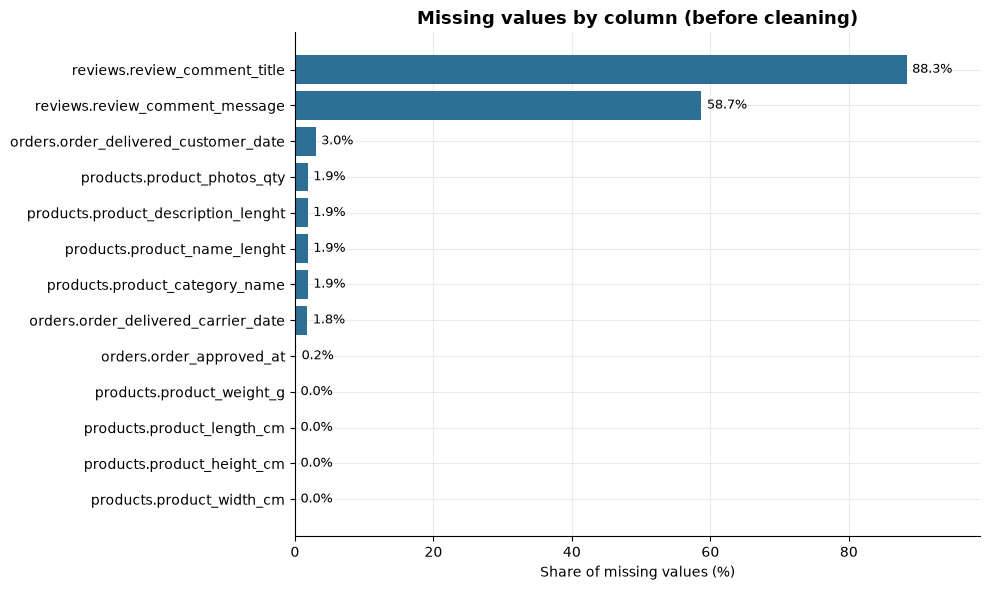

In [8]:
plot_df = missing.assign(label=missing["table"] + "." + missing["column"]).sort_values("pct")

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(plot_df["label"], plot_df["pct"], color=BLUE)
for y, v in enumerate(plot_df["pct"]):
    ax.text(v + 0.8, y, f"{v:.1f}%", va="center", fontsize=9)
ax.set_xlim(0, plot_df["pct"].max() * 1.12)
ax.set_xlabel("Share of missing values (%)")
ax.set_title("Missing values by column (before cleaning)")
save_fig("01_missing_values")

**Reading the table**
- `review_comment_title` / `review_comment_message` are optional free text — empty is normal, not an error.
- Missing approval / carrier / delivery dates must be compared with `order_status` before deciding anything (next cell).
- A few hundred products have no category (and no name length, description length or photo count).

In [9]:
pd.crosstab(
    orders["order_status"],
    orders["order_delivered_customer_date"].isna(),
    rownames=["order_status"],
    colnames=["delivery_date_missing"],
)

delivery_date_missing,False,True
order_status,,
approved,0,2
canceled,6,619
created,0,5
delivered,96470,8
invoiced,0,314
processing,0,301
shipped,0,1107
unavailable,0,609


Most missing delivery dates belong to orders that were never delivered (canceled, unavailable, shipped, invoiced, processing…), so they are **legitimate**. A handful of orders marked `delivered` have no delivery date — that is a real anomaly.

**Decision:** keep the missing values (do not invent dates) and leave the orders without a delivery date out of the delivery-time analysis.

### 3.2 Fix data types

In [10]:
date_cols = [
    "order_purchase_timestamp", "order_approved_at", "order_delivered_carrier_date",
    "order_delivered_customer_date", "order_estimated_delivery_date",
]
for c in date_cols:
    orders[c] = pd.to_datetime(orders[c])

items["shipping_limit_date"] = pd.to_datetime(items["shipping_limit_date"])
reviews["review_creation_date"] = pd.to_datetime(reviews["review_creation_date"])
reviews["review_answer_timestamp"] = pd.to_datetime(reviews["review_answer_timestamp"])

orders[date_cols].dtypes

order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object

### 3.3 Duplicates

In [11]:
# 1) completely identical rows
print("Fully duplicated rows per table:")
print({n: int(d.duplicated().sum()) for n, d in tables.items()})

# 2) duplicated keys (a key should identify exactly one row)
print("\nDuplicated keys:")
print("  orders.order_id        :", orders["order_id"].duplicated().sum())
print("  customers.customer_id  :", customers["customer_id"].duplicated().sum())
print("  products.product_id    :", products["product_id"].duplicated().sum())
print("  sellers.seller_id      :", sellers["seller_id"].duplicated().sum())
print("  reviews.review_id      :", reviews["review_id"].duplicated().sum())
print("  reviews.order_id       :", reviews["order_id"].duplicated().sum(), "(orders reviewed more than once)")

Fully duplicated rows per table:
{'orders': 0, 'items': 0, 'payments': 0, 'reviews': 0, 'customers': 0, 'products': 0, 'sellers': 0, 'translation': 0}

Duplicated keys:
  orders.order_id        : 0
  customers.customer_id  : 0
  products.product_id    : 0
  sellers.seller_id      : 0
  reviews.review_id      : 814
  reviews.order_id       : 551 (orders reviewed more than once)


In [12]:
# Keep ONE review per order (the most recent one)
rows_before = len(reviews)
reviews = (
    reviews.sort_values("review_answer_timestamp")
           .drop_duplicates(subset="order_id", keep="last")
           .reset_index(drop=True)
)
print(f"reviews: {rows_before:,} -> {len(reviews):,} rows (one review per order)")
assert reviews["order_id"].is_unique

reviews: 99,224 -> 98,673 rows (one review per order)


In [13]:
# Optional: the geolocation table (not needed for the analysis below, but it is the classic duplicates example)
geo_path = DATA_DIR / "olist_geolocation_dataset.csv"
if geo_path.exists():
    geolocation = pd.read_csv(geo_path)
    n_dup = int(geolocation.duplicated().sum())
    print(f"geolocation: {len(geolocation):,} rows, {n_dup:,} exact duplicates ({n_dup / len(geolocation):.1%})")
    geolocation = geolocation.drop_duplicates().reset_index(drop=True)
    print(f"after drop_duplicates(): {len(geolocation):,} rows")
else:
    print("geolocation file not found - skipped (it is not used in the rest of the notebook).")

geolocation: 1,000,163 rows, 261,831 exact duplicates (26.2%)
after drop_duplicates(): 738,332 rows


**Decision for reviews:** keep one review per order (the latest). Otherwise joining `reviews` to `orders` would create duplicated orders and distort every metric.

### 3.4 Products: typos, category translation, missing category

In [14]:
products = products.rename(columns={
    "product_name_lenght": "product_name_length",
    "product_description_lenght": "product_description_length",
})

translation_map = dict(zip(translation["product_category_name"], translation["product_category_name_english"]))
no_translation = sorted(set(products["product_category_name"].dropna()) - set(translation_map))
print("Categories missing from the translation table:", no_translation)

products["category"] = (
    products["product_category_name"].map(translation_map)    # Portuguese -> English
    .fillna(products["product_category_name"])                 # no translation: keep the Portuguese name
    .fillna("unknown")                                         # category missing
)
products["category"].value_counts().head(10).to_frame("products")

Categories missing from the translation table: ['pc_gamer', 'portateis_cozinha_e_preparadores_de_alimentos']


,products
category,
bed_bath_table,3029
sports_leisure,2867
furniture_decor,2657
health_beauty,2444
housewares,2335
auto,1900
computers_accessories,1639
toys,1411
watches_gifts,1329


### 3.5 Sanity checks and outliers

In [15]:
checks = pd.Series({
    "items with price <= 0": (items["price"] <= 0).sum(),
    "items with negative freight": (items["freight_value"] < 0).sum(),
    "items with zero freight": (items["freight_value"] == 0).sum(),
    "payments with value = 0": (payments["payment_value"] == 0).sum(),
    "payments with 0 instalments": (payments["payment_installments"] == 0).sum(),
    "orders approved before purchase": (orders["order_approved_at"] < orders["order_purchase_timestamp"]).sum(),
    "orders delivered before purchase": (orders["order_delivered_customer_date"] < orders["order_purchase_timestamp"]).sum(),
    "review scores outside 1-5": (~reviews["review_score"].between(1, 5)).sum(),
    "products with weight = 0 g": (products["product_weight_g"] == 0).sum(),
}, name="rows")
checks.to_frame()

,rows
items with price <= 0,0
items with negative freight,0
items with zero freight,383
payments with value = 0,9
payments with 0 instalments,2
orders approved before purchase,0
orders delivered before purchase,0
review scores outside 1-5,0
products with weight = 0 g,4


In [16]:
# Outliers in price: IQR rule (used for information only, nothing is deleted)
q1, q3 = items["price"].quantile([0.25, 0.75])
upper_fence = q3 + 1.5 * (q3 - q1)
share_out = (items["price"] > upper_fence).mean()
print(f"IQR upper fence for price: {upper_fence:,.2f} BRL -> {share_out:.1%} of items are above it")
print(f"median price: {items['price'].median():,.2f} | mean: {items['price'].mean():,.2f} | max: {items['price'].max():,.2f}")

IQR upper fence for price: 277.40 BRL -> 7.5% of items are above it
median price: 74.99 | mean: 120.65 | max: 6,735.00


**Decision:** there are no impossible prices or negative values, and only a tiny number of odd payment rows, so nothing is deleted. The high prices are real (expensive products), therefore **outliers are kept**; I compare medians with means and use clipped views when plotting.

### 3.6 Incomplete time periods

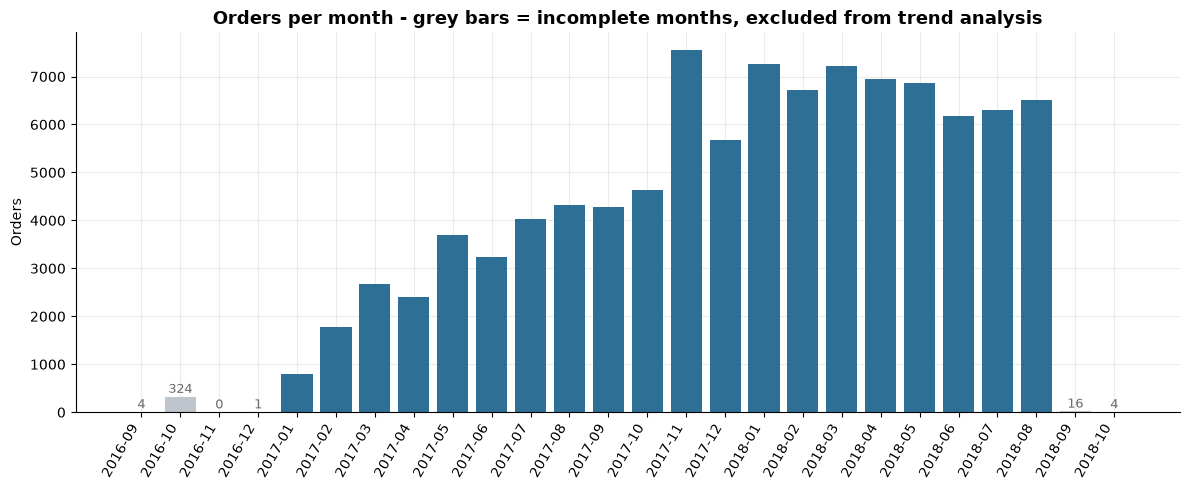

In [17]:
orders["purchase_month"] = orders["order_purchase_timestamp"].dt.to_period("M")
START, END = pd.Period("2017-01"), pd.Period("2018-08")      # complete months used for trend analysis

orders_per_month = orders.groupby("purchase_month").size()
full_range = pd.period_range(orders_per_month.index.min(), orders_per_month.index.max(), freq="M")
orders_per_month = orders_per_month.reindex(full_range, fill_value=0)      # make empty months visible
bar_colors = [BLUE if START <= m <= END else GREY for m in orders_per_month.index]

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(orders_per_month.index.astype(str), orders_per_month.values, color=bar_colors)
for x, (m, v) in enumerate(orders_per_month.items()):
    if not (START <= m <= END):
        ax.text(x, v + 80, f"{v:,}", ha="center", fontsize=9, color="dimgray")   # show how tiny these months are
ax.set_title("Orders per month - grey bars = incomplete months, excluded from trend analysis")
ax.set_ylabel("Orders")
plt.xticks(rotation=60, ha="right")
save_fig("02_orders_per_month_coverage")

2016 contains only a few months of data and Sept–Oct 2018 contain just a handful of orders (the extract stops there). Comparing those months with full months would show a fake "growth" and a fake "collapse", so **trend analysis uses complete months only: 2017-01 → 2018-08**.

### 3.7 Cleaning log

| # | Issue found | Affected | Action |
|---|---|---|---|
| 1 | Date columns stored as text | 8 columns in 3 tables | Converted to `datetime` |
| 2 | Orders with more than one review | 551 orders (99,224 → 98,673 review rows) | Kept the latest review per order |
| 3 | Missing delivery dates | 2,965 orders (only 8 of them are `delivered`) | Kept (legitimate for undelivered orders); the 8 `delivered` orders without a date are excluded from the delivery analysis |
| 4 | Missing product category | 610 products (1.85%) | Filled with `unknown` |
| 5 | Category names in Portuguese (some without translation) | 2 categories missing from the 71-row translation table | Mapped to English; untranslated names kept as they are |
| 6 | Misspelled column names in `products` | 2 columns | Renamed |
| 7 | Price outliers | 7.5% of items above 277.40 BRL (IQR rule) | Kept (real expensive products); medians and clipped plots used |
| 8 | Incomplete months (2016, Sept–Oct 2018) | 349 orders (0.4% of all orders) | Excluded from trend analysis |
| 9 | Canceled / unavailable orders | 1,234 orders (625 + 609) | Excluded from revenue and sales analysis |
| 10 | Odd but harmless values | 9 payments with value 0, 2 with 0 instalments, 4 products with 0 g weight | Kept (too few to affect the results) |
| 11 | Exact duplicate rows in `geolocation` (optional table) | 261,831 of 1,000,163 rows (26.2%) | Removed with `drop_duplicates()` |

## 4. Build the analysis tables

Golden rule: **aggregate the child tables to one row per order *before* joining**, otherwise an order with 3 items and 2 payments would appear 6 times. An `assert` at the end proves that no order was duplicated.

In [18]:
# --- one row per order for items and payments
items_per_order = items.groupby("order_id").agg(
    n_items=("order_item_id", "count"),
    items_value=("price", "sum"),
    freight_value=("freight_value", "sum"),
).reset_index()

payments_per_order = payments.groupby("order_id").agg(
    payment_value=("payment_value", "sum"),
    max_installments=("payment_installments", "max"),
).reset_index()

first_payment = (
    payments.sort_values(["order_id", "payment_sequential"])
            .drop_duplicates("order_id")[["order_id", "payment_type"]]
)

# --- order-level table
order_df = (
    orders
    .merge(customers[["customer_id", "customer_unique_id", "customer_city", "customer_state"]], on="customer_id", how="left")
    .merge(items_per_order, on="order_id", how="left")
    .merge(payments_per_order, on="order_id", how="left")
    .merge(first_payment, on="order_id", how="left")
    .merge(reviews[["order_id", "review_score"]], on="order_id", how="left")
)
assert order_df["order_id"].is_unique and len(order_df) == len(orders), "a join duplicated orders!"

# --- delivery metrics (in days)
purchase = order_df["order_purchase_timestamp"]
delivered_at = order_df["order_delivered_customer_date"]
estimated = order_df["order_estimated_delivery_date"]
order_df["delivery_days"] = (delivered_at - purchase).dt.total_seconds() / 86400            # purchase -> delivery
order_df["estimated_days"] = (estimated - purchase).dt.total_seconds() / 86400              # promised time
order_df["delay_days"] = (delivered_at.dt.normalize() - estimated.dt.normalize()).dt.days   # > 0 means late

# --- item-level table (for category analysis)
EXCLUDED = ["canceled", "unavailable"]
items_full = (
    items
    .merge(products[["product_id", "category"]], on="product_id", how="left")
    .merge(sellers[["seller_id", "seller_state"]], on="seller_id", how="left")
    .merge(orders[["order_id", "order_status", "purchase_month"]], on="order_id", how="left")
)
assert len(items_full) == len(items), "a join duplicated items!"
items_full = items_full[~items_full["order_status"].isin(EXCLUDED)]

# --- analysis scopes
sales = order_df[~order_df["order_status"].isin(EXCLUDED) & order_df["items_value"].notna()].copy()
sales_trend = sales[(sales["purchase_month"] >= START) & (sales["purchase_month"] <= END)]
delivered = order_df[(order_df["order_status"] == "delivered") & order_df["delivery_days"].notna()].copy()
delivered["is_late"] = delivered["delay_days"] > 0

print(f"order_df {order_df.shape} | sales {sales.shape} | delivered {delivered.shape} | items_full {items_full.shape}")

order_df (99441, 22) | sales (98199, 22) | delivered (96470, 23) | items_full (112101, 11)


## 5. Exploratory Data Analysis

### 5.1 Headline KPIs

In [19]:
on_time_rate = 1 - delivered["is_late"].mean()

kpis = {
    "Orders (excl. canceled / unavailable)": sales["order_id"].nunique(),
    "Unique customers": sales["customer_unique_id"].nunique(),
    "Active sellers": items_full["seller_id"].nunique(),
    "Distinct products sold": items_full["product_id"].nunique(),
    "Product revenue (BRL)": sales["items_value"].sum(),
    "Freight revenue (BRL)": sales["freight_value"].sum(),
    "Average order value (BRL)": sales["items_value"].mean(),
    "Median order value (BRL)": sales["items_value"].median(),
    "Average review score (1-5)": sales["review_score"].mean(),
    "Delivered on time (%)": on_time_rate * 100,
}
for name, value in kpis.items():
    print(f"{name:<42}{value:>16,.2f}")

Orders (excl. canceled / unavailable)            98,199.00
Unique customers                                 94,983.00
Active sellers                                    3,053.00
Distinct products sold                           32,729.00
Product revenue (BRL)                        13,494,400.74
Freight revenue (BRL)                         2,241,126.29
Average order value (BRL)                           137.42
Median order value (BRL)                             86.90
Average review score (1-5)                            4.12
Delivered on time (%)                                93.23


### 5.2 Orders and revenue over time (complete months only)

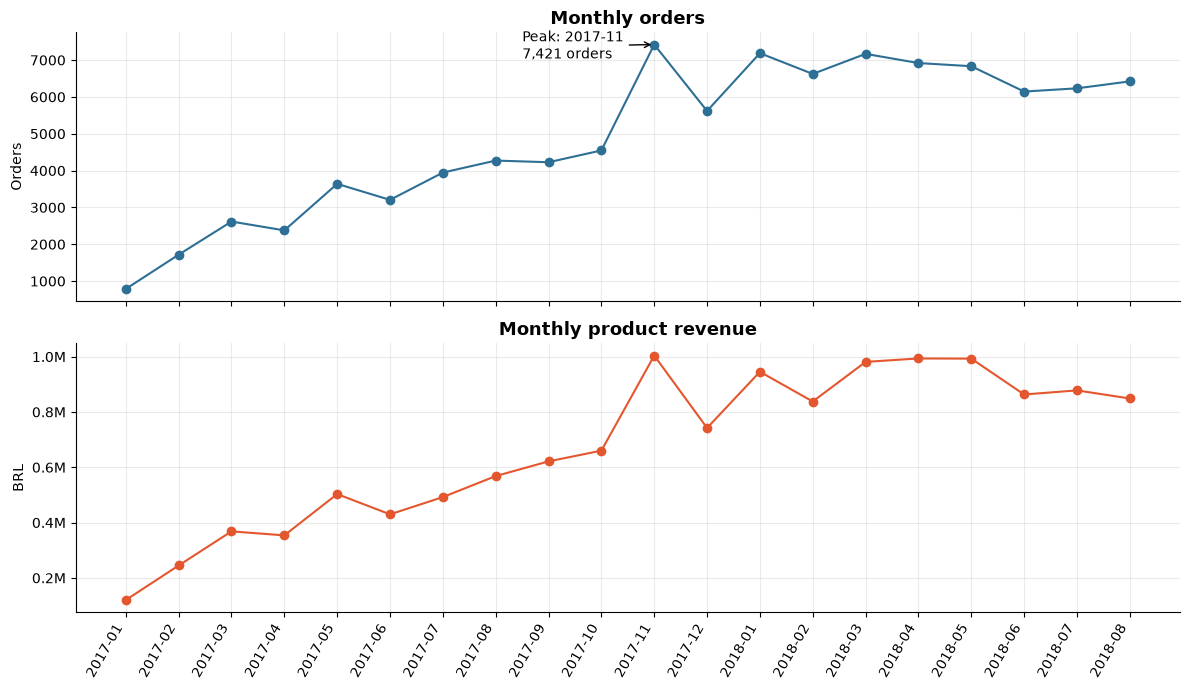

In [20]:
monthly = (
    sales_trend.groupby("purchase_month")
               .agg(orders=("order_id", "nunique"), revenue=("items_value", "sum"))
)
monthly.index = monthly.index.astype(str)

peak_month = monthly["orders"].idxmax()
peak_orders = monthly["orders"].max()

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].plot(monthly.index, monthly["orders"], marker="o", color=BLUE)
axes[0].set_title("Monthly orders")
axes[0].set_ylabel("Orders")
axes[0].annotate(f"Peak: {peak_month}\n{peak_orders:,} orders", xy=(peak_month, peak_orders),
                 xytext=(-95, -10), textcoords="offset points",
                 arrowprops=dict(arrowstyle="->", color="black"))

axes[1].plot(monthly.index, monthly["revenue"], marker="o", color=ORANGE)
axes[1].set_title("Monthly product revenue")
axes[1].set_ylabel("BRL")
axes[1].yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x / 1e6:.1f}M"))
plt.xticks(rotation=60, ha="right")
save_fig("03_monthly_orders_revenue")

In [21]:
# like-for-like growth: Jan-Aug 2018 vs Jan-Aug 2017
def jan_aug(year):
    m = sales_trend["purchase_month"]
    return sales_trend[(m >= pd.Period(f"{year}-01")) & (m <= pd.Period(f"{year}-08"))]

growth_orders = jan_aug(2018)["order_id"].nunique() / jan_aug(2017)["order_id"].nunique() - 1
growth_rev = jan_aug(2018)["items_value"].sum() / jan_aug(2017)["items_value"].sum() - 1
print(f"Jan-Aug 2018 vs Jan-Aug 2017: orders {growth_orders:+.0%}, revenue {growth_rev:+.0%}")

daily = sales.groupby(sales["order_purchase_timestamp"].dt.normalize()).size()
top_day, top_day_orders = daily.idxmax(), daily.max()
print(f"Busiest day: {top_day:%Y-%m-%d} with {top_day_orders:,} orders (daily average: {daily.mean():.0f})")

Jan-Aug 2018 vs Jan-Aug 2017: orders +137%, revenue +138%
Busiest day: 2017-11-24 with 1,166 orders (daily average: 160)


### 5.3 When do customers buy? (weekday and hour)

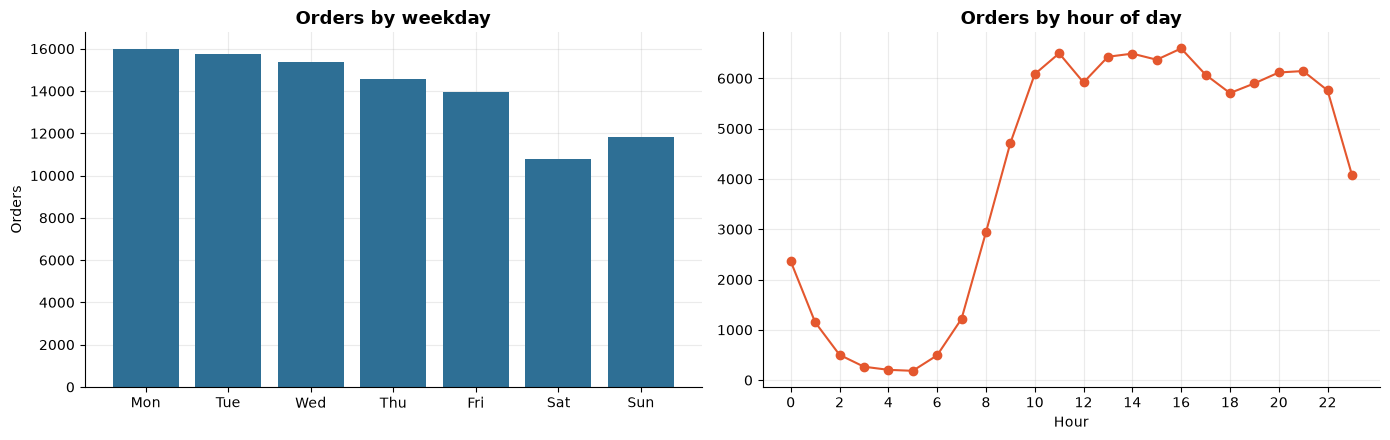

Busiest weekday: Monday | quietest: Saturday | busiest hour: 16:00


In [22]:
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
by_weekday = sales["order_purchase_timestamp"].dt.day_name().value_counts().reindex(weekday_order)
by_hour = sales["order_purchase_timestamp"].dt.hour.value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].bar(by_weekday.index.str[:3], by_weekday.values, color=BLUE)
axes[0].set_title("Orders by weekday")
axes[0].set_ylabel("Orders")

axes[1].plot(by_hour.index, by_hour.values, marker="o", color=ORANGE)
axes[1].set_xticks(range(0, 24, 2))
axes[1].set_title("Orders by hour of day")
axes[1].set_xlabel("Hour")
save_fig("04_weekday_hour_patterns")

print(f"Busiest weekday: {by_weekday.idxmax()} | quietest: {by_weekday.idxmin()} | busiest hour: {by_hour.idxmax()}:00")

### 5.4 Product categories

,revenue,items_sold,avg_price,revenue_share_pct
category,,,,
health_beauty,"1,255,695.13",9634,130.34,9.31
watches_gifts,"1,198,185.21",5970,200.70,8.88
bed_bath_table,"1,035,964.06",11097,93.36,7.68
sports_leisure,"979,740.92",8590,114.06,7.26
computers_accessories,"904,322.02",7781,116.22,6.70
furniture_decor,"727,465.05",8298,87.67,5.39
housewares,"626,825.80",6915,90.65,4.65
cool_stuff,"620,770.49",3779,164.27,4.60
auto,"586,585.73",4204,139.53,4.35


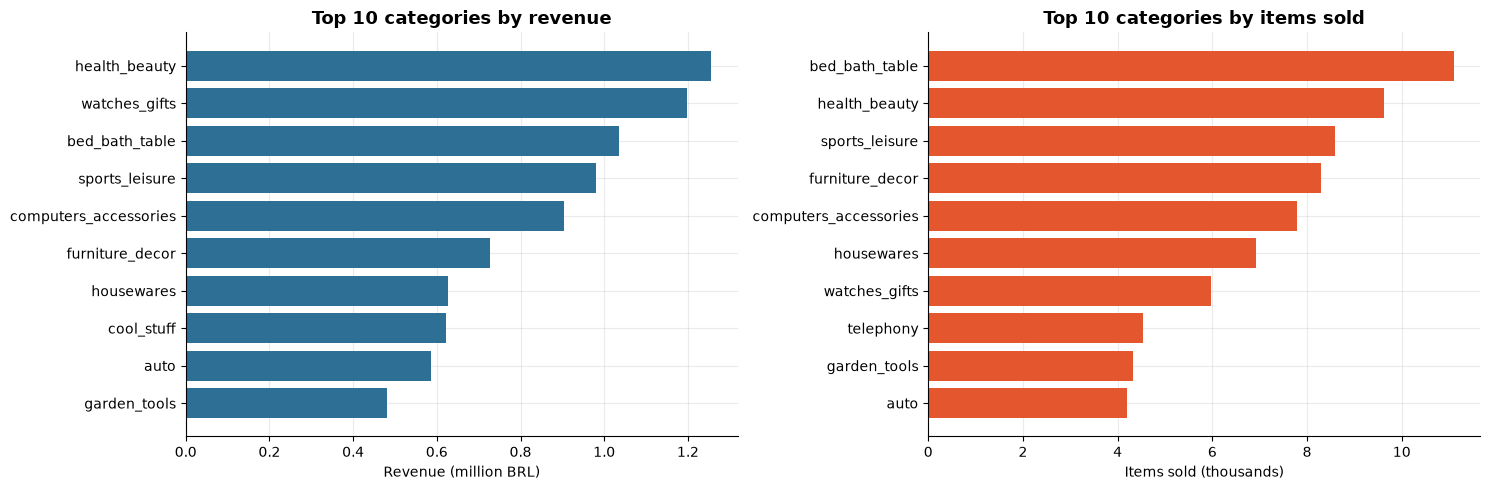

The top 5 categories generate 40% of product revenue


In [23]:
cat = (
    items_full.groupby("category")
              .agg(revenue=("price", "sum"), items_sold=("order_item_id", "count"), avg_price=("price", "mean"))
              .sort_values("revenue", ascending=False)
)
cat["revenue_share_pct"] = cat["revenue"] / cat["revenue"].sum() * 100
display(cat.head(10))

top_rev = cat.head(10).iloc[::-1]
top_qty = cat.sort_values("items_sold", ascending=False).head(10).iloc[::-1]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].barh(top_rev.index, top_rev["revenue"] / 1e6, color=BLUE)
axes[0].set_title("Top 10 categories by revenue")
axes[0].set_xlabel("Revenue (million BRL)")
axes[1].barh(top_qty.index, top_qty["items_sold"] / 1e3, color=ORANGE)
axes[1].set_title("Top 10 categories by items sold")
axes[1].set_xlabel("Items sold (thousands)")
save_fig("05_top_categories")

top5_share = cat["revenue"].head(5).sum() / cat["revenue"].sum()
print(f"The top 5 categories generate {top5_share:.0%} of product revenue")

### 5.5 Geography — customer states

,orders,revenue,avg_order_value,avg_delivery_days,revenue_share_pct
customer_state,,,,,
SP,41125,"5,163,867.22",125.57,8.76,38.27
RJ,12697,"1,811,623.42",142.68,15.31,13.43
MG,11496,"1,573,508.20",136.87,12.01,11.66
RS,5415,"742,559.78",137.13,15.30,5.50
PR,4982,"676,883.06",135.87,11.99,5.02
SC,3599,"518,578.28",144.09,14.95,3.84
BA,3344,"507,108.83",151.65,19.34,3.76
DF,2120,"300,886.45",141.93,12.97,2.23
GO,1998,"287,870.46",144.08,15.61,2.13


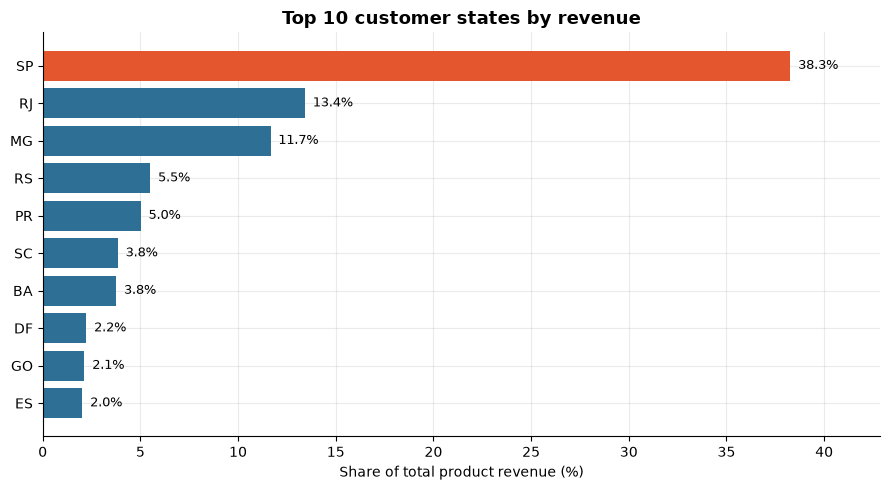

The top 3 states (SP, RJ, MG) generate 63% of revenue


In [24]:
state = (
    sales.groupby("customer_state")
         .agg(orders=("order_id", "nunique"), revenue=("items_value", "sum"),
              avg_order_value=("items_value", "mean"), avg_delivery_days=("delivery_days", "mean"))
         .sort_values("revenue", ascending=False)
)
state["revenue_share_pct"] = state["revenue"] / state["revenue"].sum() * 100
display(state.head(10))

top_states = state.head(10).iloc[::-1]
lead_state = state.index[0]

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top_states.index, top_states["revenue_share_pct"],
        color=[ORANGE if s == lead_state else BLUE for s in top_states.index])
for y, v in enumerate(top_states["revenue_share_pct"]):
    ax.text(v + 0.4, y, f"{v:.1f}%", va="center", fontsize=9)
ax.set_xlim(0, top_states["revenue_share_pct"].max() * 1.12)
ax.set_xlabel("Share of total product revenue (%)")
ax.set_title("Top 10 customer states by revenue")
save_fig("06_revenue_by_state")

top3_state_share = state["revenue_share_pct"].head(3).sum() / 100
print(f"The top 3 states ({', '.join(state.index[:3])}) generate {top3_state_share:.0%} of revenue")

### 5.6 Payments

,orders,avg_order_value,median_order_value
payment_type,,,
boleto,19535,121.71,74.99
credit_card,75613,142.88,89.90
debit_card,1515,119.61,70.00
voucher,1535,86.05,53.99


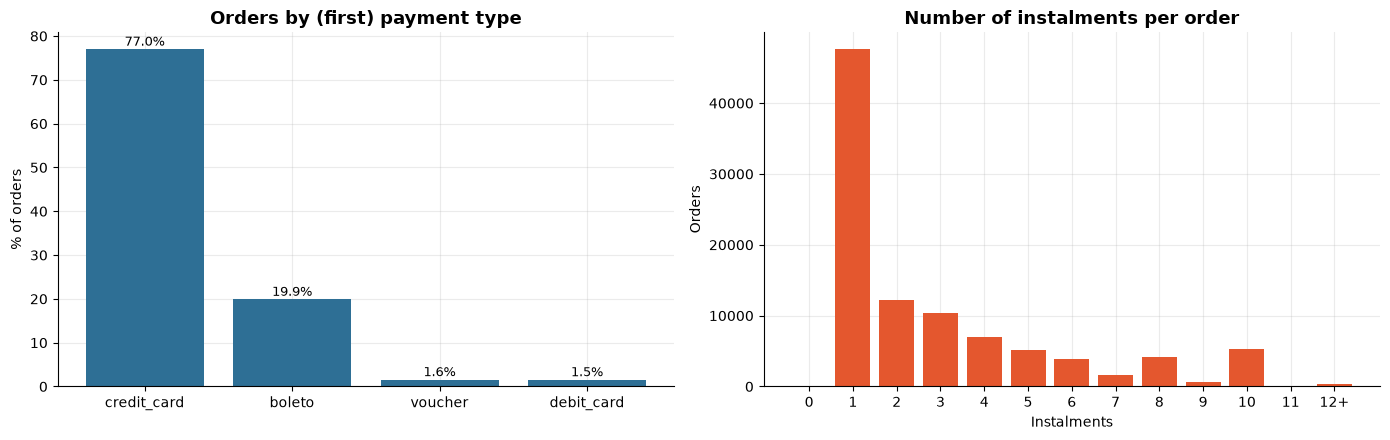

Credit card: 77% of orders | boleto: 20% | orders paid in 2+ instalments: 52%


In [25]:
pay_share = sales["payment_type"].value_counts(normalize=True) * 100
display(sales.groupby("payment_type")["items_value"].agg(orders="count", avg_order_value="mean", median_order_value="median"))

installments = sales["max_installments"].dropna().clip(upper=12).astype(int).value_counts().sort_index()
inst_labels = [str(i) if i < 12 else "12+" for i in installments.index]

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].bar(pay_share.index, pay_share.values, color=BLUE)
for x, v in enumerate(pay_share.values):
    axes[0].text(x, v + 0.8, f"{v:.1f}%", ha="center", fontsize=9)
axes[0].set_title("Orders by (first) payment type")
axes[0].set_ylabel("% of orders")

axes[1].bar(inst_labels, installments.values, color=ORANGE)
axes[1].set_title("Number of instalments per order")
axes[1].set_xlabel("Instalments")
axes[1].set_ylabel("Orders")
save_fig("07_payments")

cc_share = pay_share.get("credit_card", 0) / 100
boleto_share = pay_share.get("boleto", 0) / 100
share_instalments = (sales["max_installments"] > 1).mean()
print(f"Credit card: {cc_share:.0%} of orders | boleto: {boleto_share:.0%} | orders paid in 2+ instalments: {share_instalments:.0%}")

### 5.7 Price distribution

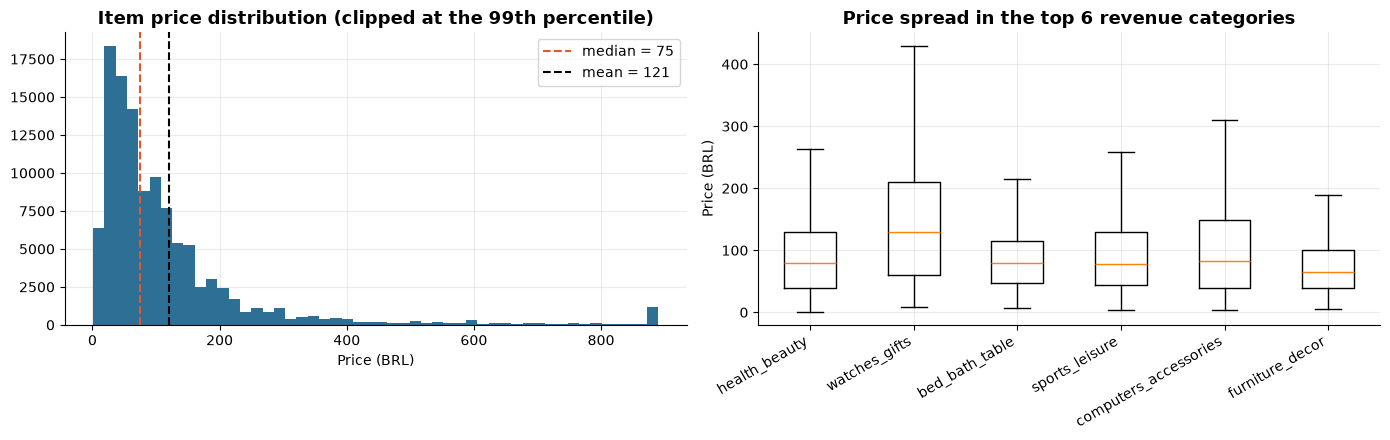

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].hist(items["price"].clip(upper=items["price"].quantile(0.99)), bins=50, color=BLUE)
axes[0].axvline(items["price"].median(), color=ORANGE, linestyle="--", label=f"median = {items['price'].median():.0f}")
axes[0].axvline(items["price"].mean(), color="black", linestyle="--", label=f"mean = {items['price'].mean():.0f}")
axes[0].set_title("Item price distribution (clipped at the 99th percentile)")
axes[0].set_xlabel("Price (BRL)")
axes[0].legend()

top6 = cat.head(6).index.tolist()
price_by_cat = [items_full.loc[items_full["category"] == c, "price"] for c in top6]
axes[1].boxplot(price_by_cat, showfliers=False)
axes[1].set_xticks(range(1, len(top6) + 1))
axes[1].set_xticklabels(top6, rotation=30, ha="right")
axes[1].set_title("Price spread in the top 6 revenue categories")
axes[1].set_ylabel("Price (BRL)")
save_fig("08_price_distribution")

### 5.8 Delivery performance

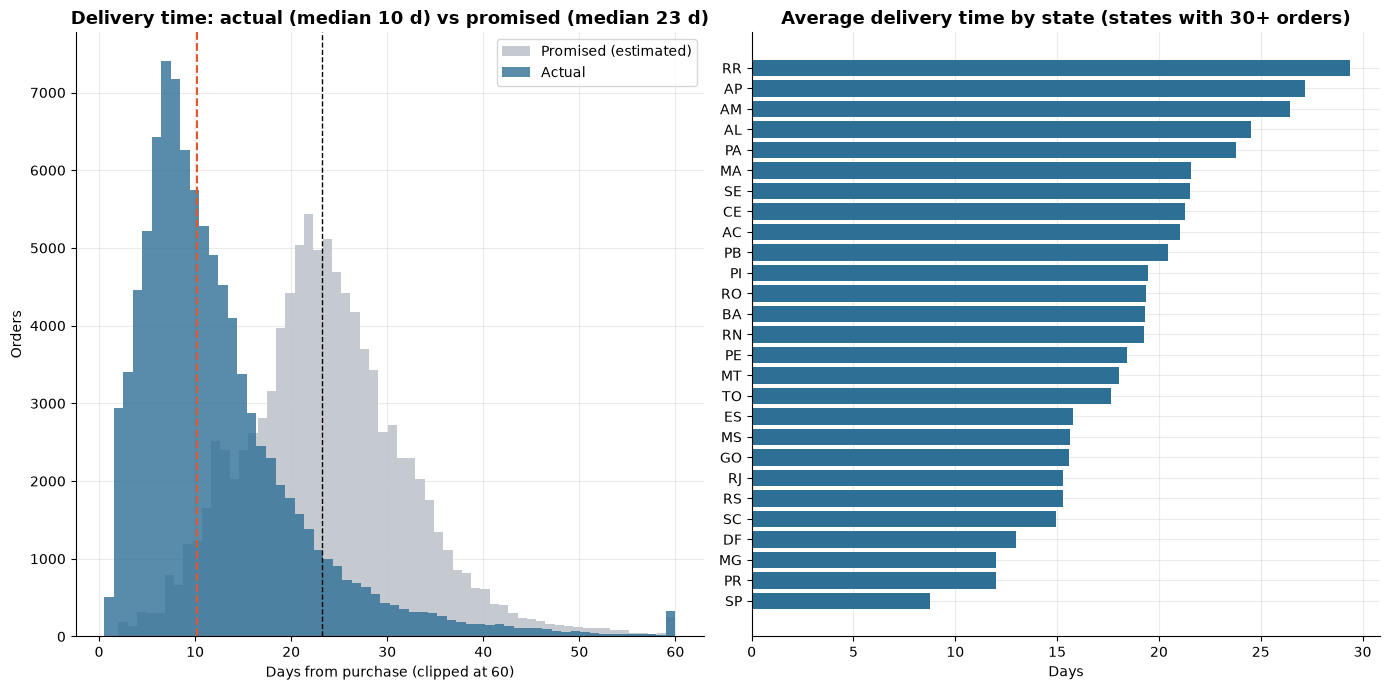

Median delivery: 10.2 days vs 23.2 days promised | late orders: 6.8%
Late orders are late by a median of 7 days
Slowest state: RR (29 days) | fastest: SP (9 days)


In [27]:
med_delivery = delivered["delivery_days"].median()
med_estimate = delivered["estimated_days"].median()
late_rate = delivered["is_late"].mean()

MIN_ORDERS = 30
state_delivery = delivered.groupby("customer_state")["delivery_days"].agg(["mean", "count"])
state_delivery = state_delivery[state_delivery["count"] >= MIN_ORDERS].sort_values("mean")

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
axes[0].hist(delivered["estimated_days"].clip(upper=60), bins=60, color=GREY, alpha=0.9, label="Promised (estimated)")
axes[0].hist(delivered["delivery_days"].clip(upper=60), bins=60, color=BLUE, alpha=0.8, label="Actual")
axes[0].axvline(med_estimate, color="black", linestyle="--", linewidth=1)
axes[0].axvline(med_delivery, color=ORANGE, linestyle="--", linewidth=1.5)
axes[0].set_title(f"Delivery time: actual (median {med_delivery:.0f} d) vs promised (median {med_estimate:.0f} d)")
axes[0].set_xlabel("Days from purchase (clipped at 60)")
axes[0].set_ylabel("Orders")
axes[0].legend()

axes[1].barh(state_delivery.index, state_delivery["mean"], color=BLUE)
axes[1].set_title(f"Average delivery time by state (states with {MIN_ORDERS}+ orders)")
axes[1].set_xlabel("Days")
save_fig("09_delivery_performance")

print(f"Median delivery: {med_delivery:.1f} days vs {med_estimate:.1f} days promised | late orders: {late_rate:.1%}")
print(f"Late orders are late by a median of {delivered.loc[delivered['is_late'], 'delay_days'].median():.0f} days")
slow_state, slow_days = state_delivery["mean"].idxmax(), state_delivery["mean"].max()
fast_state, fast_days = state_delivery["mean"].idxmin(), state_delivery["mean"].min()
print(f"Slowest state: {slow_state} ({slow_days:.0f} days) | fastest: {fast_state} ({fast_days:.0f} days)")

### 5.9 Customer reviews and late deliveries

,avg_score,orders
delay_bucket,,
Early (1+ days),4.29,88163
On the estimated day,4.03,1280
1-3 days late,3.29,1852
4-7 days late,2.10,1748
8+ days late,1.70,2781


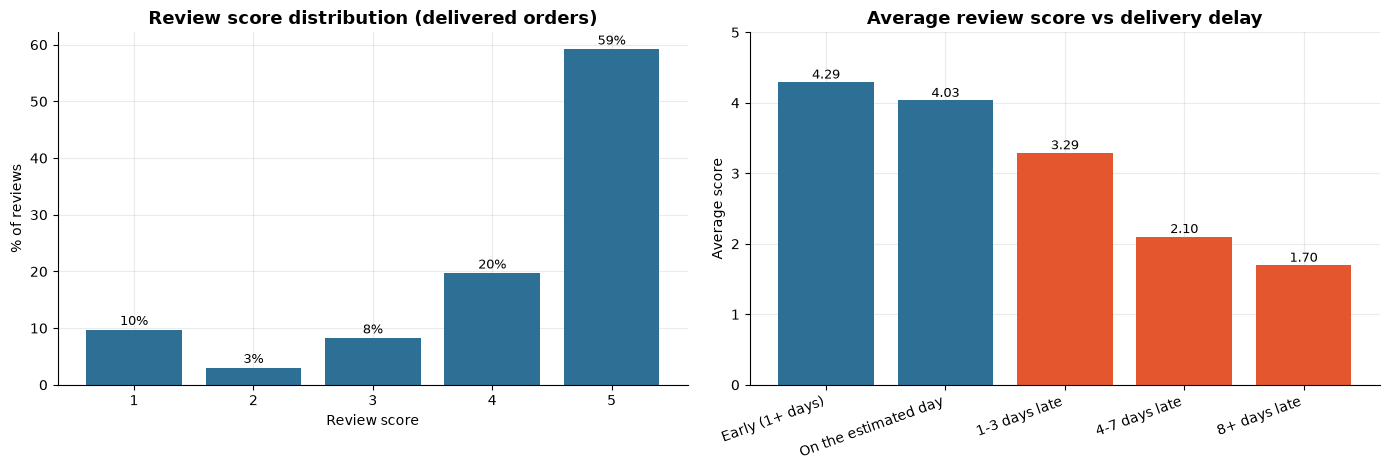

Average score: 4.29 (on time) vs 2.27 (late)
Share of 1-star reviews: 7% (on time) vs 54% (late)


In [28]:
rated = delivered.dropna(subset=["review_score"])
score_dist = rated["review_score"].value_counts(normalize=True).sort_index() * 100

bucket_labels = ["Early (1+ days)", "On the estimated day", "1-3 days late", "4-7 days late", "8+ days late"]
rated = rated.assign(delay_bucket=pd.cut(rated["delay_days"], bins=[-np.inf, -1, 0, 3, 7, np.inf], labels=bucket_labels))
by_bucket = rated.groupby("delay_bucket", observed=True)["review_score"].agg(avg_score="mean", orders="count")
display(by_bucket)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
axes[0].bar(score_dist.index.astype(int).astype(str), score_dist.values, color=BLUE)
for x, v in enumerate(score_dist.values):
    axes[0].text(x, v + 0.8, f"{v:.0f}%", ha="center", fontsize=9)
axes[0].set_title("Review score distribution (delivered orders)")
axes[0].set_xlabel("Review score")
axes[0].set_ylabel("% of reviews")

bar_cols = [ORANGE if "late" in str(b) else BLUE for b in by_bucket.index]
axes[1].bar(by_bucket.index.astype(str), by_bucket["avg_score"], color=bar_cols)
for x, v in enumerate(by_bucket["avg_score"]):
    axes[1].text(x, v + 0.05, f"{v:.2f}", ha="center", fontsize=9)
axes[1].set_ylim(0, 5)
axes[1].set_title("Average review score vs delivery delay")
axes[1].set_ylabel("Average score")
plt.setp(axes[1].get_xticklabels(), rotation=20, ha="right")
save_fig("10_reviews_vs_delay")

on_time_scores = rated.loc[~rated["is_late"], "review_score"]
late_scores = rated.loc[rated["is_late"], "review_score"]
avg_on_time, avg_late = on_time_scores.mean(), late_scores.mean()
one_star_on_time, one_star_late = (on_time_scores == 1).mean(), (late_scores == 1).mean()
print(f"Average score: {avg_on_time:.2f} (on time) vs {avg_late:.2f} (late)")
print(f"Share of 1-star reviews: {one_star_on_time:.0%} (on time) vs {one_star_late:.0%} (late)")

### 5.10 Customer loyalty

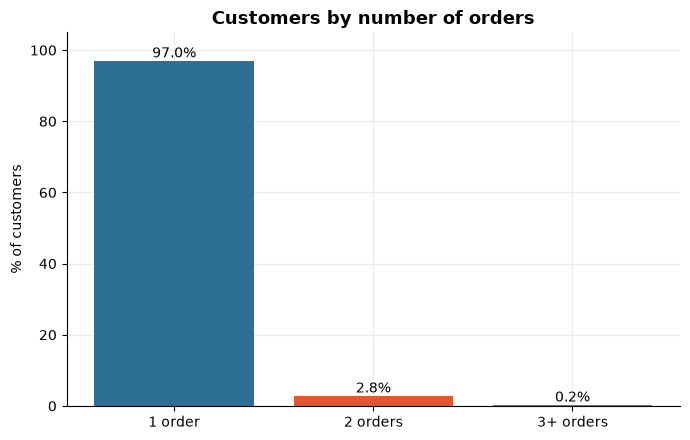

Only 3.0% of customers placed more than one order


In [29]:
orders_per_customer = sales.groupby("customer_unique_id")["order_id"].nunique()
repeat_rate = (orders_per_customer > 1).mean()

dist = orders_per_customer.clip(upper=3).value_counts().sort_index()
dist_pct = dist / dist.sum() * 100
names = {1: "1 order", 2: "2 orders", 3: "3+ orders"}

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar([names[i] for i in dist_pct.index], dist_pct.values, color=[BLUE if i == 1 else ORANGE for i in dist_pct.index])
for x, v in enumerate(dist_pct.values):
    ax.text(x, v + 1, f"{v:.1f}%", ha="center", fontsize=10)
ax.set_ylim(0, 105)
ax.set_ylabel("% of customers")
ax.set_title("Customers by number of orders")
save_fig("11_customer_loyalty")

print(f"Only {repeat_rate:.1%} of customers placed more than one order")

### 5.11 Correlations (delivered orders)

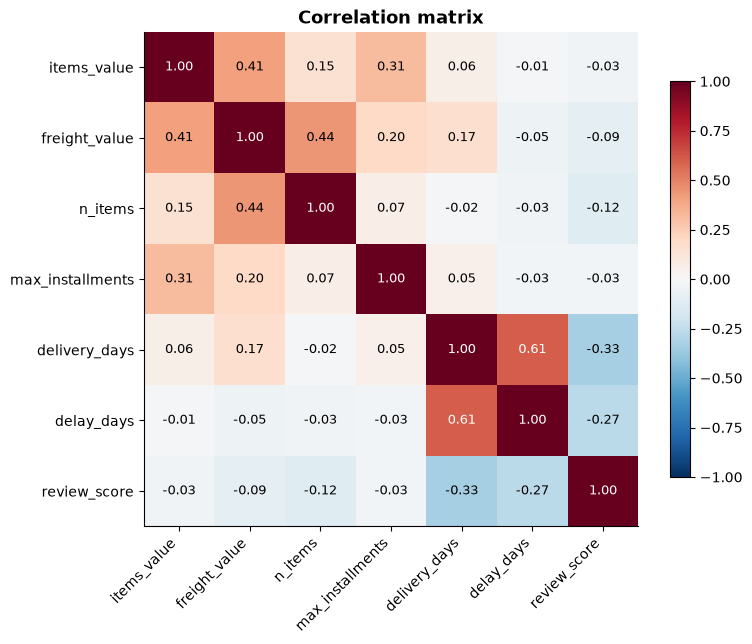

,correlation with review_score
delivery_days,-0.33
delay_days,-0.27
n_items,-0.12
freight_value,-0.09
items_value,-0.03
max_installments,-0.03


In [30]:
num_cols = ["items_value", "freight_value", "n_items", "max_installments", "delivery_days", "delay_days", "review_score"]
corr = delivered[num_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6.5))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(num_cols)))
ax.set_xticklabels(num_cols, rotation=45, ha="right")
ax.set_yticks(range(len(num_cols)))
ax.set_yticklabels(num_cols)
ax.grid(False)
for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        value = corr.iloc[i, j]
        ax.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=9,
                color="white" if abs(value) > 0.5 else "black")
fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_title("Correlation matrix")
save_fig("12_correlation_heatmap")

corr["review_score"].drop("review_score").sort_values().to_frame("correlation with review_score")

## 6. Key findings

The numbers below are computed from the analysis above (nothing is typed by hand).

In [31]:
print("KEY FINDINGS")
print("-" * 70)
print(f"1. Growth      : Jan-Aug 2018 orders {growth_orders:+.0%} and revenue {growth_rev:+.0%} vs Jan-Aug 2017.")
print(f"2. Seasonality : busiest month {peak_month} ({peak_orders:,} orders); busiest day {top_day:%Y-%m-%d} ({top_day_orders:,} orders).")
print(f"3. Concentration: top 5 categories = {top5_share:.0%} of revenue; top 3 states ({', '.join(state.index[:3])}) = {top3_state_share:.0%}.")
print(f"4. Payments    : {cc_share:.0%} of orders paid by credit card, {boleto_share:.0%} by boleto; {share_instalments:.0%} paid in 2+ instalments.")
print(f"5. Delivery    : median {med_delivery:.0f} days vs {med_estimate:.0f} days promised; {late_rate:.1%} of orders arrive late.")
print(f"6. Geography   : delivery takes {slow_days:.0f} days in {slow_state} vs {fast_days:.0f} days in {fast_state}.")
print(f"7. Satisfaction: average review {avg_on_time:.2f} when on time vs {avg_late:.2f} when late; 1-star reviews {one_star_on_time:.0%} vs {one_star_late:.0%}.")
print(f"8. Loyalty     : only {repeat_rate:.1%} of customers ordered more than once.")

KEY FINDINGS
----------------------------------------------------------------------
1. Growth      : Jan-Aug 2018 orders +137% and revenue +138% vs Jan-Aug 2017.
2. Seasonality : busiest month 2017-11 (7,421 orders); busiest day 2017-11-24 (1,166 orders).
3. Concentration: top 5 categories = 40% of revenue; top 3 states (SP, RJ, MG) = 63%.
4. Payments    : 77% of orders paid by credit card, 20% by boleto; 52% paid in 2+ instalments.
5. Delivery    : median 10 days vs 23 days promised; 6.8% of orders arrive late.
6. Geography   : delivery takes 29 days in RR vs 9 days in SP.
7. Satisfaction: average review 4.29 when on time vs 2.27 when late; 1-star reviews 7% vs 54%.
8. Loyalty     : only 3.0% of customers ordered more than once.


## 7. Insights, recommendations and limitations

*Every number below comes from the outputs and charts above (sections 3–6).*

**Bottom line:** the marketplace grew fast in 2017 and delivers well ahead of its promised dates, but customers punish the few late deliveries severely (average review 2.27 vs 4.29), and 97% of them never place a second order.

**Insights**
- *Growth:* Jan–Aug 2018 had **137% more orders** (and 138% more revenue) than Jan–Aug 2017, but most of that growth happened in 2017: monthly orders rose from under 1,000 in January 2017 to a peak of **7,421 in November 2017**, and since January 2018 they hover around 6–7k with no further growth.
- *Seasonality:* the November 2017 peak is Black Friday. The busiest day in the data (2017-11-24) had **1,166 orders**, more than seven times the daily average of 160. Monday is the busiest weekday, Saturday the quietest, and orders peak around 16:00.
- *Where the money is:* revenue is diversified across categories but concentrated geographically. The top 5 categories generate **40%** of product revenue (the largest, `health_beauty`, only 9.3%), whereas **São Paulo alone brings 38.3%** and SP + RJ + MG together **63%**. Rankings depend on the metric: `bed_bath_table` sells the most items (11,097) but is 3rd by revenue, while `watches_gifts` is 2nd by revenue with about half as many items thanks to the highest average price of the top 10 (200.70 BRL).
- *Payments:* **77%** of orders are paid by credit card (boleto: 20%) and **52%** in two or more instalments. Credit-card orders are also larger on average (142.88 BRL vs 121.71 for boleto), so instalments look like an important part of how customers buy.
- *Delivery:* fast on average, uneven in the tail and across regions. The median order arrives in **10.2 days vs 23.2 promised** and 93.2% arrive on or before the promised date, so the estimates are very conservative. The 6.8% of late orders are not marginal: they are late by a **median of 7 days**. Delivery takes **29 days in RR vs 9 in SP**, and even large markets such as RJ (15.3 days) and BA (19.3 days) are well behind SP.
- *Delivery vs. satisfaction:* the clearest pattern in the data. The average review is **4.29 for on-time orders vs 2.27 for late orders**, and **54% of late orders get a 1-star review vs 7%** of on-time ones. The longer the delay, the lower the score: 3.29 (1–3 days late), 2.10 (4–7 days), 1.70 (8+ days). Delivery time is the strongest correlate of the score (−0.33), while order value (−0.03) and instalments (−0.03) are almost unrelated to it.
- *Retention:* only **3.0% of customers ordered more than once**; 97.0% bought exactly once. Growth therefore depends almost entirely on acquiring new customers.

**Recommendations**
1. **Attack the late tail, not the median.** Delivery is already fast on average, but the 6.8% of orders that arrive late receive a 1-star review 54% of the time. Flag orders at risk of missing their date, warn the customer proactively, and prioritise carrier and seller improvements in the slowest states (RR 29 days, BA 19 days).
2. **Invest in retention.** With only 3.0% of customers coming back, even a small rise in repeat purchases would reduce the dependence on new customers. A follow-up e-mail, voucher or loyalty programme after the first delivered order is a simple place to start. It should go together with a punctual first delivery; whether late first orders really reduce repeat purchases is still a hypothesis (see next steps).
3. **Prepare for peak days.** Black Friday 2017 brought 1,166 orders in a single day. Plan stock, seller response times and carrier capacity ahead of November, since late deliveries are what customers penalise most.
4. **Reduce the dependence on a few states, but fix logistics first.** SP, RJ and MG generate 63% of revenue. The other states are the growth opportunity, but they also wait longer for their orders (RJ 15 days and BA 19 days vs 9 in SP), so marketing outside the top 3 should go together with logistics improvements there. Category concentration is a smaller risk (the top category is 9.3% of revenue).

**Limitations**
- Data covers 2016–2018 only; 2016 and Sept–Oct 2018 are incomplete (349 orders in total) and were excluded from the trends.
- There is no cost or margin information: "revenue" here means item prices (freight excluded), not profit.
- The +137% growth compares Jan–Aug 2018 with the platform's early ramp-up in 2017, so it overstates the recent trend: monthly orders have been flat since January 2018.
- Reviews are optional, so the review sample may be biased toward very happy or very unhappy customers.
- Correlation is not causation: late deliveries are associated with lower scores, but other factors (product quality, the seller, multi-item orders) may play a role.
- Delivery times are analysed by customer state only; seller location, and therefore shipping distance, is not part of the analysis.

**Next steps (ideas)**
- Test whether customers whose first order arrived late are less likely to buy again (links delivery to retention).
- Compare seller state with customer state to see how much of the regional delivery gap is explained by distance.
- RFM customer segmentation.
- Text analysis of the (Portuguese) review comments.
- A model that predicts the probability of a late delivery.
- An interactive dashboard in Power BI / Tableau / Streamlit.